Dean Hickman

Spring 2025

CS 343: Neural Networks

Project 1: Single-layer networks

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from adaline import Adaline

# Set the color style so that Professor Layton can see your plots
plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
# Make the font size larger
plt.show()
plt.rcParams.update({'font.size': 18})

# Turn off scientific notation when printing
np.set_printoptions(suppress=True, precision=3)

# Automatically reload your external source code
%load_ext autoreload
%autoreload 2


def plot_adaline_train(net, loss_list, acc_list, plotMarkers=False, title='ADALINE'):
    '''Helper plotting function provided for you.'''
    n_epochs = len(loss_list)

    x = np.arange(1, n_epochs+1)

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
    fig.suptitle(f'{title} ({n_epochs} epochs)')

    curveStr = '-r'
    if plotMarkers:
        curveStr += 'o'

    ax1.plot(x, loss_list, curveStr)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss (Sum squared error)')
    ax2.plot(x, acc_list, curveStr)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')

    plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


**Paste in your code to load Old Faithful data with standardized features below**

In [4]:
pathname ='/Users/deanehickman/Downloads/cs343/dehick 1/old_faithful - old_faithful.csv'
df = pd.read_csv(pathname)
features = df.iloc[:, 1:3]
#print(features.shape)
output_classes = df.iloc[:, 3]
#print(output_classes.shape)

mu = features.mean()
sigma = features.std()
#print(mu, sigma)

standardized = (features - mu)/sigma

X= standardized.to_numpy()
y= output_classes




## Task 4: Neural network for regression

Given ADALINE's linear (identity) activation and sum-of-squares loss function, the learned weights can be used for more than just classification. In this task, you will use ADALINE to perform a linear regression (*the same neural network offers another interpretation of what you did in CS251!*).

### Goal

Your goal is to get an ADALINE network to predict `waiting` from `eruptions`. That is, you are setting up a simple (bivariate) linear regression with equation $$y_i = m \times x_i + b$$where the "x" variable (*predictor variable*) is `eruptions` and the "y" variable (*response variable*) is `waiting` (raw).

**Ultimately, you want to draw a regression line *through* the Old Faithful data clusters to *join* rather than divide them.**

### Design

You can do the regression with the exact network you have currently implemented. **You shouldn't make any code changes to your `Adaline` class.**  In the cell below, use your network to set up the regression by making appropriate design choices:
- Network input features: How many? What should they be?
- Weights: What do they mean in this problem context?
- What are the "classes"?

### Tips

- I suggest using the standardized version of the predictor (otherwise you may run into numeric stability issues), but it's fine to use the raw/unstandardized response variable. 
- Default hyperparameters should work well.
- You may need to add a singleton dimension after selecting your input predictor feature below so that your existing code works i.e. `shape=(272,1)`, NOT `shape=(272,)`

**Write your training code in the cell below.**

In [5]:

X = features.iloc[:, 0].to_numpy().reshape(-1,1)  
mu = X.mean()
sigma = X.std()
X = (X - mu) / sigma

y = features.iloc[:, 1].to_numpy()   

model = Adaline()
loss_history, accuracy_history = model.fit(X, y, n_epochs=1000, lr=0.001, r_seed=0)

b = model.get_bias()
m = model.get_wts()[0]

In the cell below, **create a scatter plot of the data and the overlayed regression line**. Have the x-axis map onto standardized `eruptions` and y-axis onto raw `waiting` values.

### Tips
- You will need to leverage the model linear equation to go from x values to predicted y values. $y_i = m \times x_i + b$
- Look at the class boundary plot code that you used for classification. You will need to generate linearly spaced x values before plotting your regression y values on your regression line. 

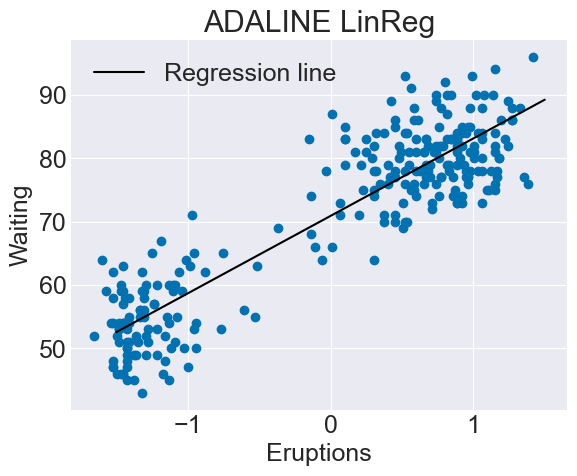

In [6]:
x_axis = np.linspace(-1.5, 1.5, 50)
y_axis = m * x_axis + b

fig, ax = plt.subplots()
ax.scatter(X, y)
ax.plot(x_axis, y_axis, color='black', label='Regression line')
ax.set_xlabel('Eruptions')
ax.set_ylabel('Waiting')
ax.set_title('ADALINE LinReg')
ax.legend()
plt.show()

## Task 5: ADALINE and logistic regression

In this task, you will extend ADALINE to logistic regression, where we explicitly represent the probability of class membership.

For example data point $i$ is 80% likely to be in class A and 20% in class B.

**Remember:** Despite the name, logistic regression is actually about solving a **classification** problem. So this is more similar to Task 3 than Task 4.

### 5a. Implement logistic regression

Create a subclass of `Adaline` called `AdalineLogistic` in a new file called `adaline_logistic.py`. **Only override existing methods as needed to make the following changes. DO NOT MODIFY `adaline.py` FOR ANY REASON!!**.

#### Design

1. Use the sigmoid activation function. $z = f(x) = \frac{1}{1+e^{-x}}$
2. Represent the output classes as 0 or +1. This should require a code change (activation values >=0.5 are classified as 1, otherwise class 0) and preprocessing of the old faithful data.
3. Use the cross-entropy loss function: $\sum_{i=1}^n \left [ -y_i Log(z_i) - (1-y_i)Log(1 - z_i) \right ] $
where $z_i$ is the activation to input sample $i$ and $y_i$ is the corresponding $i^{th}$ class label (0 or 1).


#### Todo below:

1. Train your network using the standardized Old Faithful data. Default hyperparameters should work fine.
2. Plot your loss and accuracy as a function of epoch.
3. Plot the logistic regression decision boundary and the data (Use your code from Task 2).

#### Questions

**Question 11.** Why do we need to relabel the classes from -1/+1 to 0/1 when training a logistic regression network?

**Answer 11:**

Our goal is to represent the labels as a proballistic description on the data. The data is either going to be in the correct class (1) or the wrong class (0). Our sigmoid activation functions restricts the magnitude of netAct to a value between (0,1) and classifies the data based on that values relation to the activation threshold (0.5). As a result, it makes the most sense to change our label naming-convention to reflect how the activation function and class labels describe the way the data is being classified.

In [7]:
from adaline_logistic import AdalineLogistic

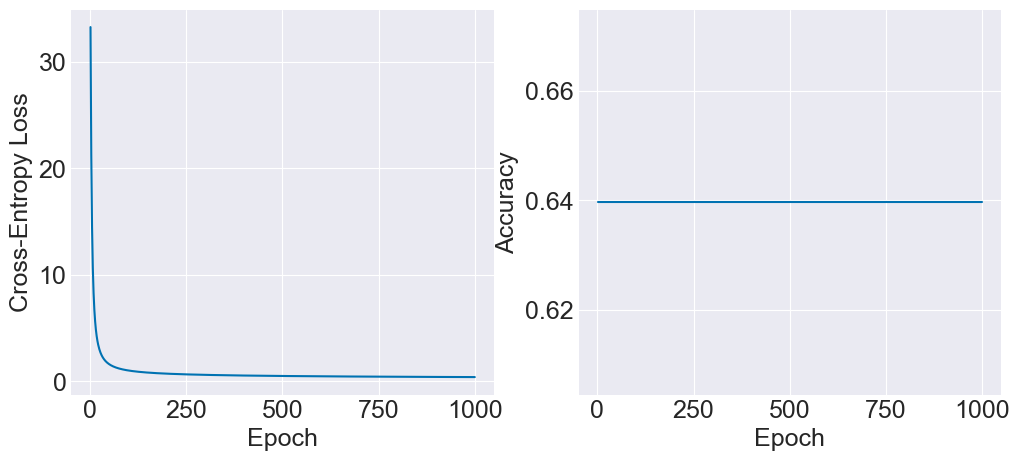

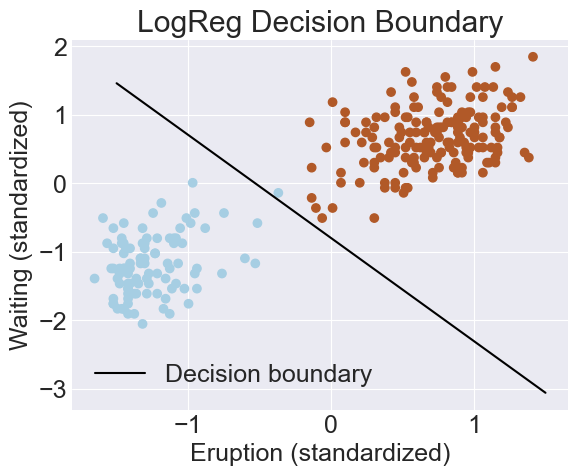

In [8]:
pathname ='/Users/deanehickman/Downloads/cs343/dehick 1/old_faithful - old_faithful.csv'
df = pd.read_csv(pathname)
features = df.iloc[:, 1:3]
#print(features.shape)
output_classes = df.iloc[:, 3]
#print(output_classes.shape)

mu = features.mean()
sigma = features.std()
#print(mu, sigma)

standardized = (features - mu)/sigma

X= standardized.to_numpy()
output_classes = np.where(output_classes == -1, 0, output_classes)

model = AdalineLogistic()
loss_history, accuracy_history = model.fit(X, output_classes, n_epochs=1000, lr=0.001, r_seed=0)

epochs= range(1, len(loss_history)+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))
ax1.plot(epochs, loss_history)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax2.plot(epochs, accuracy_history)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
plt.show()

wts = model.get_wts()
bias = model.get_bias()

m = wts[0]/wts[1]
b = bias/wts[1]


x_axis = np.linspace(-1.5, 1.5, 50)
y_axis = -(m * x_axis + b)

fig, ax = plt.subplots()
scatter = ax.scatter(X[:, 0], X[:, 1], c=output_classes, cmap='Paired')
ax.plot(x_axis, y_axis, color='black', label='Decision boundary')
ax.set_xlabel('Eruption (standardized)')
ax.set_ylabel('Waiting (standardized)')
ax.set_title('LogReg Decision Boundary')
ax.legend()
plt.show()



### 5b. Test point probabilities

#### Questions

**Question 12.** (a) Determine the probability that the following test points belong to **both classes**:

Format: standardized (eruptions, waiting)
- (0.4, 0.98)
- (0.5, -2)
- (-1, 0.5)

(b) Interpret what your probabilities make sense in light of decision boundary plot you made in Task 5a.

**Answer 12:**

Based on the decision boundary plot, I expect the model to classify the data with high confidence. The classes appear to be nearly linearly separable, with most data points clustered on either side of the boundary. This visual separation suggests that the model should produce activation probabilities close to 0 or 1, rather than near the threshold of 0.5.

The outputs reflect this: one function gives continuous probabilities (activation values from the sigmoid function), while the other gives uniform class predictions (0 or 1). This difference comes from the activation threshold (0.5) which maps the activation probabilities to class labels. The model applies this threshold to the activation outputs to determine the predicted class for each input.

In [9]:
test_points =np.array([[0.4, 0.98], [0.5, -2], [-1, 0.5]])

standardized = (test_points - mu.to_numpy())/ sigma.to_numpy()

probas = model.activation(standardized)
print("Probabilities of test_points belonging to the positive class:\n" , probas)
print("Probabilities of test_points belonging to the negative class:\n", 1- probas)

probas = model.predict(standardized)

print("Discrete classification of test_points belonging to the positive class:", probas)
print("Discrete classification of test_points belonging to the negative class:", 1 - probas)



Probabilities of test_points belonging to the positive class:
 [[0.063 0.006]
 [0.068 0.005]
 [0.019 0.006]]
Probabilities of test_points belonging to the negative class:
 [[0.937 0.994]
 [0.932 0.995]
 [0.981 0.994]]
Discrete classification of test_points belonging to the positive class: [0 0 0]
Discrete classification of test_points belonging to the negative class: [1 1 1]
